# Gradient-descent IMF with parallel local windows

This notebook demonstrates the intrinsic multiscale filtering idea from `IMF.pdf`
with a smooth robust contrast and gradient descent.


## Setup

The signal length is fixed at `n = 1000`. The first symmetric discrete window is the
nearest odd size above half the sample length, so the first window contains `501`
points.


In [39]:
import os
import time
from concurrent.futures import ThreadPoolExecutor
from numpy.lib.stride_tricks import sliding_window_view

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


rng = np.random.default_rng(42)

SQRT_2 = np.sqrt(2.0)
SQRT_2_OVER_PI = np.sqrt(2.0 / np.pi)
DEFAULT_MAX_WORKERS = 12

plt.rcParams.update({
    "figure.figsize": (11, 4),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DEFAULT_MAX_WORKERS


12

## IMF formulation

For a contrast function $\rho$, kernel $K$, and bandwidth $h_k$, stage $k$
solves one scalar local problem at each time index:

$$
\widetilde S_t^{(k)}
= \operatorname{arginf}_x
\sum_u \rho_H\left(Y_u^{(k)} - x\right)K_{h_k}(t-u).
$$

After the local fits are computed, the residual is updated by

$$
Y_t^{(k+1)} = Y_t^{(k)} - \widetilde S_t^{(k)}.
$$

That residual update makes the stages sequential. The local problems inside a fixed
stage are independent, so those window fits are the parallel part.


In [40]:
def odd_ceiling(value):
    size = int(np.ceil(value))
    if size % 2 == 0:
        size += 1
    return max(1, size)


def nearest_odd(value):
    rounded = int(np.round(value))
    if rounded % 2 == 1:
        return max(1, rounded)

    lower = max(1, rounded - 1)
    upper = rounded + 1
    if abs(value - lower) <= abs(upper - value):
        return lower
    return upper


def make_window_schedule(n, factor=np.sqrt(2.0), min_window_size=31):
    if n <= 0:
        raise ValueError("n must be positive")
    if factor <= 1:
        raise ValueError("factor must be larger than 1")

    first = odd_ceiling(n / 2)
    if first > n:
        first = n if n % 2 == 1 else n - 1

    min_size = nearest_odd(min_window_size)
    if min_size > first:
        return [first]

    sizes = [first]
    current = first

    while current > min_size:
        candidate = nearest_odd(current / factor)
        candidate = min(candidate, current - 2)
        if candidate % 2 == 0:
            candidate -= 1
        if candidate < min_size:
            candidate = min_size

        sizes.append(candidate)
        current = candidate

    return sizes


def gen_signal(t):
    slow = 0.6 * np.sin(2 * np.pi * t)
    medium = 0.25 * np.sin(12 * np.pi * t)
    bump = 0.8 * np.exp(-((t - 0.55) ** 2) / (2 * 0.015 ** 2))
    trend = 0.5 * (t - 0.5)

    x = slow + medium + bump + trend

    components = {
        "slow": slow,
        "medium": medium,
        "bump": bump,
        "trend": trend,
    }
    return x, components


def generate_observation(
    x,
    sigma=0.1,
    contamination_prob=0.05,
    contamination_scale=0.1,
    centered_contamination=False,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    gaussian_noise = rng.normal(loc=0.0, scale=sigma, size=len(x))
    contamination_mask = rng.random(len(x)) < contamination_prob
    exponential_noise = rng.exponential(scale=contamination_scale, size=len(x))

    if centered_contamination:
        exponential_noise = exponential_noise - contamination_scale

    contamination = contamination_mask * exponential_noise

    sign = rng.choice([-1, 1], size=len(x))
    contamination *= sign

    y = x + gaussian_noise + contamination

    return y, {
        "gaussian_noise": gaussian_noise,
        "contamination": contamination,
        "contamination_mask": contamination_mask,
    }


n = 1000
t = np.linspace(0.0, 1.0, n)
sigma = 0.2
H = 2 * sigma

window_sizes = make_window_schedule(n, factor=np.sqrt(2.0), min_window_size=31)
x_clean, true_components = gen_signal(t)
y_observed, noise_info = generate_observation(
    x_clean,
    sigma=sigma,
    contamination_prob=0.2,
    contamination_scale=0.2,
    rng=np.random.default_rng(777),
)

assert window_sizes[0] == 501
assert all(size % 2 == 1 for size in window_sizes)
assert all(left > right for left, right in zip(window_sizes, window_sizes[1:]))
assert min(window_sizes) >= 31

window_schedule_df = pd.DataFrame({
    "stage": np.arange(1, len(window_sizes) + 1),
    "window_size": window_sizes,
    "radius": [size // 2 for size in window_sizes],
    "relative_width": np.array(window_sizes) / n,
})

window_schedule_df


,stage,window_size,radius,relative_width
0,1,501,250,0.501
1,2,355,177,0.355
2,3,251,125,0.251
3,4,177,88,0.177
4,5,125,62,0.125
5,6,89,44,0.089
6,7,63,31,0.063
7,8,45,22,0.045
8,9,31,15,0.031


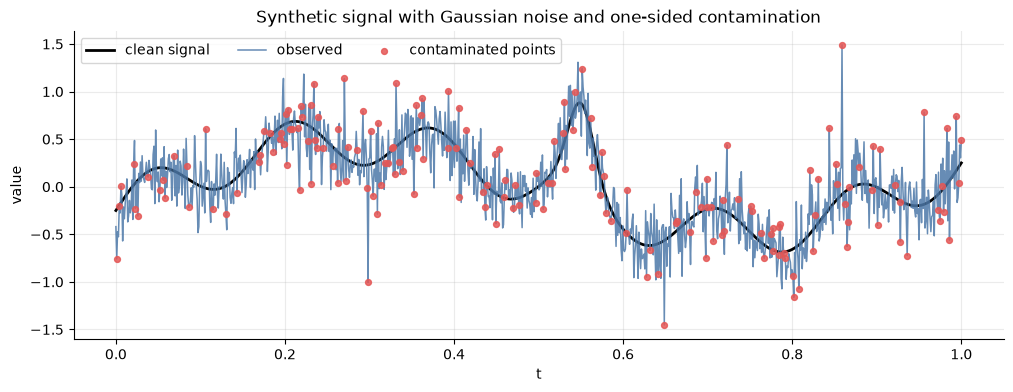

In [41]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, x_clean, color="black", linewidth=2.0, label="clean signal")
ax.plot(t, y_observed, color="#4C78A8", linewidth=1.1, alpha=0.85, label="observed")

mask = noise_info["contamination_mask"]
ax.scatter(
    t[mask],
    y_observed[mask],
    s=18,
    color="#E45756",
    alpha=0.85,
    label="contaminated points",
    zorder=3,
)

ax.set_title("Synthetic signal with Gaussian noise and one-sided contamination")
ax.set_xlabel("t")
ax.set_ylabel("value")
ax.legend(loc="upper left", ncol=3)
plt.show()


## Kernel and lookup grid

The notebook uses the Epanechnikov kernel from the PDF:

$$
K(u)=\frac{3}{4}(1-|u|)^2_+.
$$

The robust contrast is

$$
\rho_H(r)
=r\,\operatorname{erf}\left(\frac{r}{\sqrt2H}\right)
+\sqrt{2/\pi}H\exp\left(-\frac{r^2}{2H^2}\right),
$$

with score

$$
\psi_H(r)=\rho_H'(r)=\operatorname{erf}\left(\frac{r}{\sqrt2H}\right).
$$

Gradient descent repeatedly evaluates the score on large residual matrices. By writing
$z=r/H$, both the score and exponent become reusable functions of $z$. The default
path below uses a precomputed grid in $z$, with saturated tails outside the grid.


In [42]:
def epanechnikov_weights(window_size):
    if window_size % 2 == 0:
        raise ValueError("window_size must be odd")

    radius = window_size // 2
    if radius == 0:
        return np.array([1.0])

    offsets = np.arange(-radius, radius + 1)
    u = offsets / radius
    weights = 0.75 * np.maximum(0.0, 1.0 - np.abs(u)) ** 2
    return weights / weights.sum()


def erf_approx(x):
    x = np.asarray(x, dtype=float)
    sign = np.sign(x)
    ax = np.abs(x)

    p = 0.3275911
    a1 = 0.254829592
    a2 = -0.284496736
    a3 = 1.421413741
    a4 = -1.453152027
    a5 = 1.061405429

    z = 1.0 / (1.0 + p * ax)
    poly = (((((a5 * z + a4) * z + a3) * z + a2) * z + a1) * z)
    return sign * (1.0 - poly * np.exp(-(ax ** 2)))


def exact_score(residual, H):
    if H <= 0:
        raise ValueError("H must be positive")
    return erf_approx(np.asarray(residual, dtype=float) / (SQRT_2 * H))


def exact_exp(residual, H):
    if H <= 0:
        raise ValueError("H must be positive")
    z = np.asarray(residual, dtype=float) / H
    return np.exp(-0.5 * z ** 2)


def smooth_abs_rho_exact(residual, H):
    residual = np.asarray(residual, dtype=float)
    return residual * exact_score(residual, H) + SQRT_2_OVER_PI * H * exact_exp(residual, H)


def make_lookup_grid(zmax=8.0, num=4097):
    if zmax <= 0:
        raise ValueError("zmax must be positive")
    if num < 3:
        raise ValueError("num must be at least 3")

    z_grid = np.linspace(-zmax, zmax, num)
    return {
        "z": z_grid,
        "score": erf_approx(z_grid / SQRT_2),
        "exp": np.exp(-0.5 * z_grid ** 2),
        "zmax": float(zmax),
        "num": int(num),
    }


def _interp_like(values, x_grid, y_grid, left, right):
    values = np.asarray(values, dtype=float)
    flat = np.interp(values.ravel(), x_grid, y_grid, left=left, right=right)
    return flat.reshape(values.shape)


def lookup_score(residual, H, grid):
    if H <= 0:
        raise ValueError("H must be positive")
    z = np.asarray(residual, dtype=float) / H
    return _interp_like(z, grid["z"], grid["score"], left=-1.0, right=1.0)


def lookup_exp(residual, H, grid):
    if H <= 0:
        raise ValueError("H must be positive")
    z = np.asarray(residual, dtype=float) / H
    return _interp_like(z, grid["z"], grid["exp"], left=0.0, right=0.0)


def smooth_abs_rho_lookup(residual, H, grid):
    residual = np.asarray(residual, dtype=float)
    return residual * lookup_score(residual, H, grid) + SQRT_2_OVER_PI * H * lookup_exp(residual, H, grid)


lookup_grid = make_lookup_grid(zmax=8.0, num=4097)

for size in window_sizes:
    weights = epanechnikov_weights(size)
    assert np.all(weights >= 0)
    assert np.isclose(weights.sum(), 1.0)

z_validation = np.linspace(-lookup_grid["zmax"], lookup_grid["zmax"], 20001)
residual_validation = z_validation * H

score_max_error = np.max(np.abs(
    lookup_score(residual_validation, H, lookup_grid)
    - exact_score(residual_validation, H)
))
exp_max_error = np.max(np.abs(
    lookup_exp(residual_validation, H, lookup_grid)
    - exact_exp(residual_validation, H)
))
tail_exp_at_zmax = np.exp(-0.5 * lookup_grid["zmax"] ** 2)

assert score_max_error < 5e-4
assert exp_max_error < 5e-4
assert tail_exp_at_zmax < 1e-12

pd.DataFrame([
    {"quantity": "score max abs error", "value": score_max_error},
    {"quantity": "exponent max abs error", "value": exp_max_error},
    {"quantity": "exp(-zmax^2 / 2)", "value": tail_exp_at_zmax},
])


,quantity,value
0,score max abs error,9.226423e-07
1,exponent max abs error,1.906223e-06
2,exp(-zmax^2 / 2),1.266417e-14


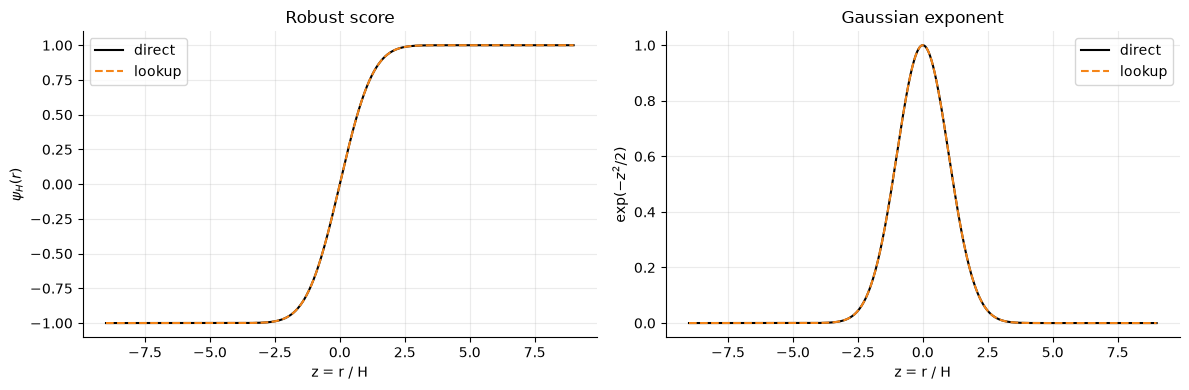

In [43]:
z_plot = np.linspace(-9.0, 9.0, 2000)
residual_plot = z_plot * H

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(z_plot, exact_score(residual_plot, H), color="black", label="direct")
axes[0].plot(
    z_plot,
    lookup_score(residual_plot, H, lookup_grid),
    color="#F58518",
    linestyle="--",
    label="lookup",
)
axes[0].set_title("Robust score")
axes[0].set_xlabel("z = r / H")
axes[0].set_ylabel(r"$\psi_H(r)$")
axes[0].legend()

axes[1].plot(z_plot, exact_exp(residual_plot, H), color="black", label="direct")
axes[1].plot(
    z_plot,
    lookup_exp(residual_plot, H, lookup_grid),
    color="#F58518",
    linestyle="--",
    label="lookup",
)
axes[1].set_title("Gaussian exponent")
axes[1].set_xlabel("z = r / H")
axes[1].set_ylabel(r"$\exp(-z^2/2)$")
axes[1].legend()

plt.tight_layout()
plt.show()


## Gradient descent over all local windows

For a fixed stage $k$, each row of `windows` is one local optimization problem.
The update is

$$
x_t^{(m+1)}
=x_t^{(m)}
+\eta\sum_u w_{t,u}\psi_H\left(Y_u^{(k)}-x_t^{(m)}\right).
$$

The code below updates many $x_t$'s at once with NumPy. When `max_workers > 1`, the
window matrix is split into chunks and each chunk solves its independent local fits in
a worker thread.


In [44]:
def robust_gd_fit_windows(
    windows,
    weights,
    H,
    grid=None,
    max_iter=60,
    tol=1e-6,
    return_trace=False,
):
    windows = np.asarray(windows, dtype=float)
    weights = np.asarray(weights, dtype=float)

    if windows.ndim != 2:
        raise ValueError("windows must be a 2D array")
    if H <= 0:
        raise ValueError("H must be positive")
    if len(windows) == 0:
        empty = np.array([], dtype=float)
        return (empty, empty) if return_trace else empty

    if grid is None:
        grid = lookup_grid

    weights = weights / weights.sum()
    row_weights = weights.reshape(1, -1)

    x = np.median(windows, axis=1)
    lower = windows.min(axis=1)
    upper = windows.max(axis=1)
    trace = []

    step = 0.95 * H / SQRT_2_OVER_PI

    for _ in range(max_iter):
        local_score = np.sum(
            row_weights * lookup_score(windows - x[:, None], H, grid),
            axis=1,
        )
        x_next = np.clip(x + step * local_score, lower, upper)
        max_delta = float(np.max(np.abs(x_next - x)))
        trace.append(max_delta)
        x = x_next

        if max_delta <= tol * (1.0 + float(np.max(np.abs(x)))):
            break

    if return_trace:
        return x, np.array(trace, dtype=float)
    return x


def _robust_filter_chunk(args):
    start, stop, windows, weights, H, grid, max_iter, tol = args
    values, trace = robust_gd_fit_windows(
        windows[start:stop],
        weights,
        H,
        grid=grid,
        max_iter=max_iter,
        tol=tol,
        return_trace=True,
    )
    return start, values, trace


def combine_traces(traces):
    if not traces:
        return np.array([], dtype=float)

    max_len = max(len(trace) for trace in traces)
    combined = np.zeros(max_len, dtype=float)

    for i in range(max_len):
        combined[i] = max(
            (trace[i] if i < len(trace) else 0.0)
            for trace in traces
        )

    return combined


def local_robust_gd_filter(
    y,
    window_size,
    H,
    grid=None,
    boundary="wrap",
    max_iter=60,
    tol=1e-6,
    max_workers=1,
    chunk_size=None,
    return_trace=False,
):
    if window_size % 2 == 0:
        raise ValueError("window_size must be odd")
    if grid is None:
        grid = lookup_grid

    y = np.asarray(y, dtype=float)
    radius = window_size // 2
    weights = epanechnikov_weights(window_size)
    y_padded = np.pad(y, pad_width=radius, mode=boundary)
    windows = sliding_window_view(y_padded, window_size)

    n_obs = len(y)
    max_workers = max(1, int(max_workers or 1))
    if chunk_size is None:
        chunk_size = n_obs if max_workers == 1 else max(64, int(np.ceil(n_obs / max_workers)))

    ranges = [
        (start, min(start + chunk_size, n_obs))
        for start in range(0, n_obs, chunk_size)
    ]

    if max_workers == 1 or len(ranges) == 1:
        values, trace = robust_gd_fit_windows(
            windows,
            weights,
            H,
            grid=grid,
            max_iter=max_iter,
            tol=tol,
            return_trace=True,
        )
        return (values, trace) if return_trace else values

    out = np.empty(n_obs, dtype=float)
    traces = []
    args = [
        (start, stop, windows, weights, H, grid, max_iter, tol)
        for start, stop in ranges
    ]

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        for start, values, trace in executor.map(_robust_filter_chunk, args):
            out[start:start + len(values)] = values
            traces.append(trace)

    trace = combine_traces(traces)
    return (out, trace) if return_trace else out


def robust_gd_imf_with_history(
    y,
    window_sizes,
    H,
    grid=None,
    boundary="wrap",
    max_iter=60,
    tol=1e-6,
    max_workers=1,
):
    residual = np.asarray(y, dtype=float).copy()
    residuals = [residual.copy()]
    imfs = []
    stage_info = []

    start_time = time.perf_counter()
    for stage_index, window_size in enumerate(window_sizes, start=1):
        imf, trace = local_robust_gd_filter(
            residual,
            window_size,
            H,
            grid=grid,
            boundary=boundary,
            max_iter=max_iter,
            tol=tol,
            max_workers=max_workers,
            return_trace=True,
        )
        imfs.append(imf)
        residual = residual - imf
        residuals.append(residual.copy())
        stage_info.append({
            "stage": stage_index,
            "window_size": window_size,
            "iterations": len(trace),
            "final_max_delta": float(trace[-1]) if len(trace) else np.nan,
            "trace": trace,
        })

    imfs = np.array(imfs)
    residuals = np.array(residuals)

    return {
        "imfs": imfs,
        "residual": residual,
        "residuals": residuals,
        "reconstruction": imfs.sum(axis=0) + residual,
        "stage_info": stage_info,
        "elapsed_seconds": time.perf_counter() - start_time,
        "H": float(H),
    }


## Run the decomposition

The default run uses the lookup grid and threaded chunks. The reconstruction check is
near machine precision because each residual is updated by direct subtraction.


In [45]:
result = robust_gd_imf_with_history(
    y_observed,
    window_sizes,
    H=H,
    grid=lookup_grid,
    max_iter=60,
    tol=1e-6,
    max_workers=DEFAULT_MAX_WORKERS,
)

sum_imfs = result["imfs"].sum(axis=0)
reconstruction_error = np.max(np.abs(y_observed - result["reconstruction"]))

assert result["imfs"].shape == (len(window_sizes), n)
assert result["residuals"].shape == (len(window_sizes) + 1, n)
assert sum_imfs.shape == y_observed.shape
assert reconstruction_error < 1e-10
assert np.allclose(sum_imfs + result["residual"], y_observed)
assert np.all(np.isfinite(result["imfs"]))
assert np.all(np.isfinite(result["residuals"]))
for info in result["stage_info"]:
    assert np.all(np.isfinite(info["trace"]))

stage_summary_rows = []

for idx, info in enumerate(result["stage_info"]):
    residual_before = result["residuals"][idx]
    residual_after = result["residuals"][idx + 1]
    imf = result["imfs"][idx]
    residual_rms_before = float(np.sqrt(np.mean(residual_before ** 2)))
    residual_rms_after = float(np.sqrt(np.mean(residual_after ** 2)))
    imf_rms = float(np.sqrt(np.mean(imf ** 2)))

    assert np.allclose(residual_before - residual_after, imf)

    stage_summary_rows.append({
        "stage": info["stage"],
        "window_size": info["window_size"],
        "iterations": info["iterations"],
        "final_max_delta": info["final_max_delta"],
        "residual_rms_before": residual_rms_before,
        "residual_rms_after": residual_rms_after,
        "imf_rms": imf_rms,
        "imf_rms_pct_before": 100.0 * imf_rms / residual_rms_before,
        "max_abs_imf": float(np.max(np.abs(imf))),
        "corr_before_after": float(np.corrcoef(residual_before, residual_after)[0, 1]),
    })

stage_summary_df = pd.DataFrame(stage_summary_rows)
assert np.all(np.isfinite(stage_summary_df.select_dtypes(include=[np.number]).to_numpy()))

print(f"elapsed seconds: {result['elapsed_seconds']:.3f}")
print(f"reconstruction max error: {reconstruction_error:.3e}")
stage_summary_df


elapsed seconds: 0.100
reconstruction max error: 2.220e-16


,stage,window_size,iterations,final_max_delta,residual_rms_before,residual_rms_after,imf_rms,imf_rms_pct_before,max_abs_imf,corr_before_after
0,1,501,14,9.681364e-07,0.448120,0.325250,0.264247,58.967997,0.396951,0.812319
1,2,355,13,1.012753e-06,0.325250,0.303384,0.049152,15.112102,0.105904,0.990175
2,3,251,14,4.469628e-07,0.303384,0.272178,0.060483,19.936194,0.186328,0.983753
3,4,177,11,9.064978e-07,0.272178,0.248237,0.066231,24.333753,0.207629,0.971795
4,5,125,9,8.961120e-07,0.248237,0.238656,0.042316,17.046731,0.162996,0.985669
5,6,89,10,6.292905e-07,0.238656,0.233807,0.024196,10.138432,0.107636,0.994966
6,7,63,10,8.073949e-07,0.233807,0.229594,0.019210,8.216088,0.069399,0.996728
7,8,45,10,3.924428e-07,0.229594,0.224777,0.016978,7.394761,0.057946,0.997432
8,9,31,10,6.998007e-07,0.224777,0.217501,0.019326,8.597754,0.082300,0.996722


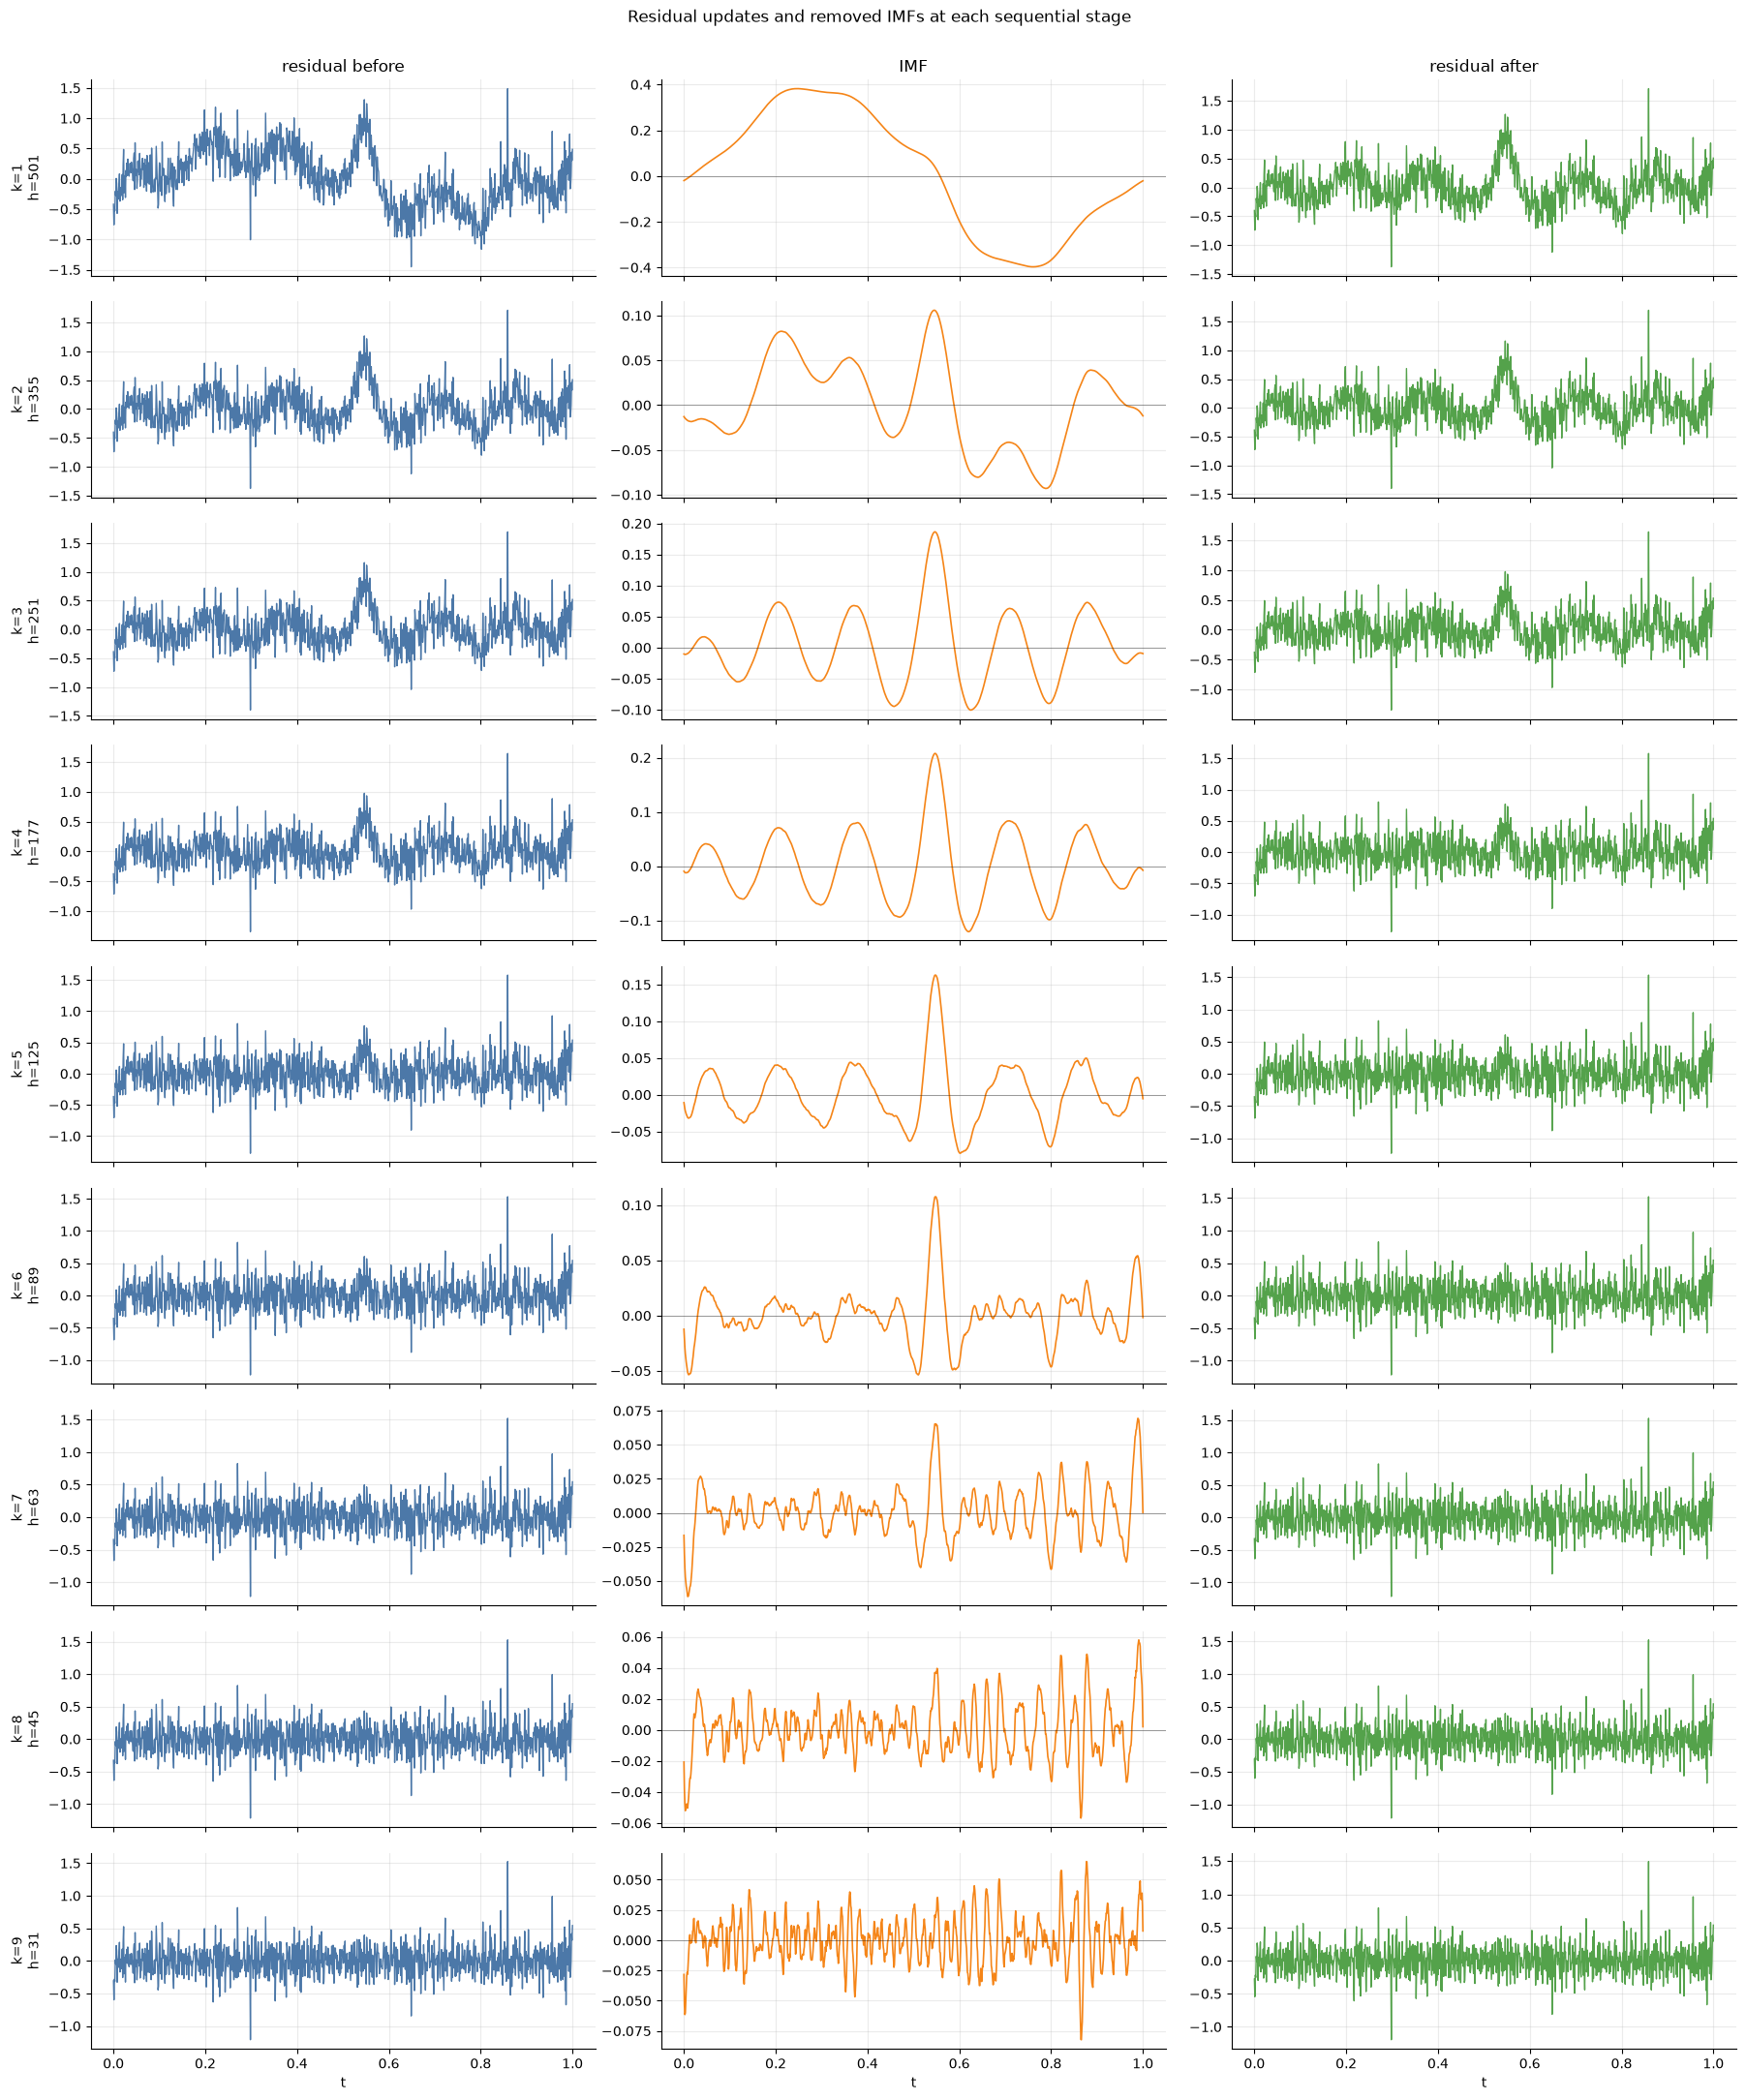

In [50]:
fig, axes = plt.subplots(
    len(window_sizes),
    3,
    figsize=(18, 2.4 * len(window_sizes)),
    sharex=True,
)

for idx, window_size in enumerate(window_sizes):
    residual_before = result["residuals"][idx]
    residual_after = result["residuals"][idx + 1]
    removed_imf = residual_before - residual_after

    assert np.allclose(removed_imf, result["imfs"][idx])

    axes[idx, 0].plot(t, residual_before, color="#4C78A8", linewidth=1.0)
    axes[idx, 1].plot(t, removed_imf, color="#F58518", linewidth=1.2)
    axes[idx, 1].axhline(0.0, color="black", linewidth=0.7, alpha=0.35)
    axes[idx, 2].plot(t, residual_after, color="#54A24B", linewidth=1.0)

    axes[idx, 0].set_ylabel(f"k={idx + 1}\nh={window_size}")
for ax, title in zip(
    axes[0],
    ["residual before", "IMF", "residual after"],
):
    ax.set_title(title)

for ax in axes[-1]:
    ax.set_xlabel("t")

fig.suptitle("Residual updates and removed IMFs at each sequential stage", y=1.002)
plt.tight_layout()
plt.show()


## Final decomposition comparison

The cumulative IMF sum is the part removed from the observation across all stages. Comparing it to the clean signal and the original observation shows what the decomposition has captured, while the final residual shows what remains.


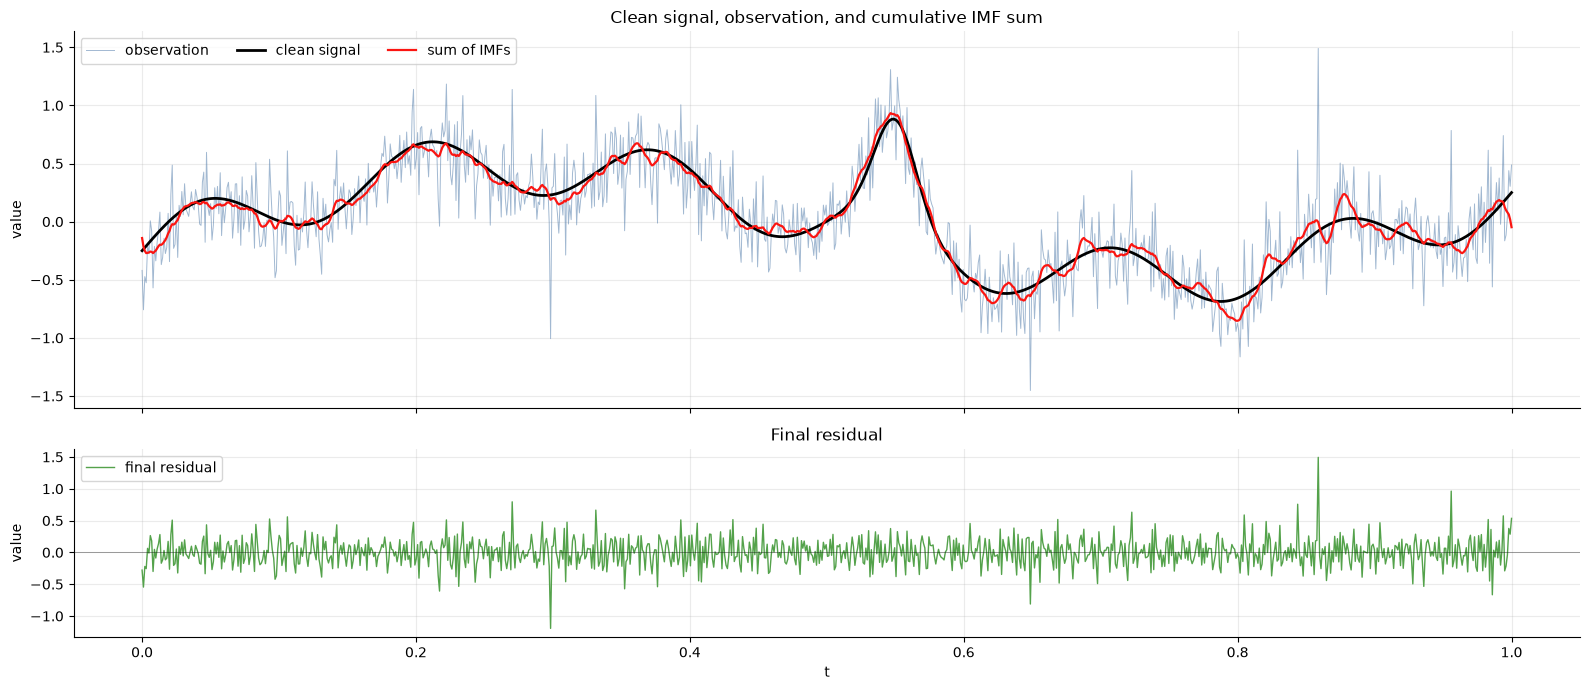

,metric,value
0,RMSE observation vs clean,0.237219
1,RMSE sum IMFs vs clean,0.065281
2,corr sum IMFs with clean,0.985807
3,final residual RMS,0.217501


In [47]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(16, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [2.0, 1.0]},
)

axes[0].plot(t, y_observed, color="#4C78A8", linewidth=0.7, alpha=0.52, label="observation")
axes[0].plot(t, x_clean, color="#000000", linewidth=2.0, label="clean signal")
axes[0].plot(t, sum_imfs, color="#FB1511", linewidth=1.6, label="sum of IMFs")
axes[0].set_title("Clean signal, observation, and cumulative IMF sum")
axes[0].set_ylabel("value")
axes[0].legend(loc="upper left", ncol=3)

axes[1].plot(t, result["residual"], color="#54A24B", linewidth=1.0, label="final residual")
axes[1].axhline(0.0, color="#000000", linewidth=0.7, alpha=0.35)
axes[1].set_title("Final residual")
axes[1].set_xlabel("t")
axes[1].set_ylabel("value")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()


def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))


decomposition_metrics_df = pd.DataFrame([
    {"metric": "RMSE observation vs clean", "value": rmse(y_observed, x_clean)},
    {"metric": "RMSE sum IMFs vs clean", "value": rmse(sum_imfs, x_clean)},
    {"metric": "corr sum IMFs with clean", "value": float(np.corrcoef(sum_imfs, x_clean)[0, 1])},
    {"metric": "final residual RMS", "value": float(np.sqrt(np.mean(result["residual"] ** 2)))},
])

assert np.all(np.isfinite(decomposition_metrics_df["value"].to_numpy()))
decomposition_metrics_df


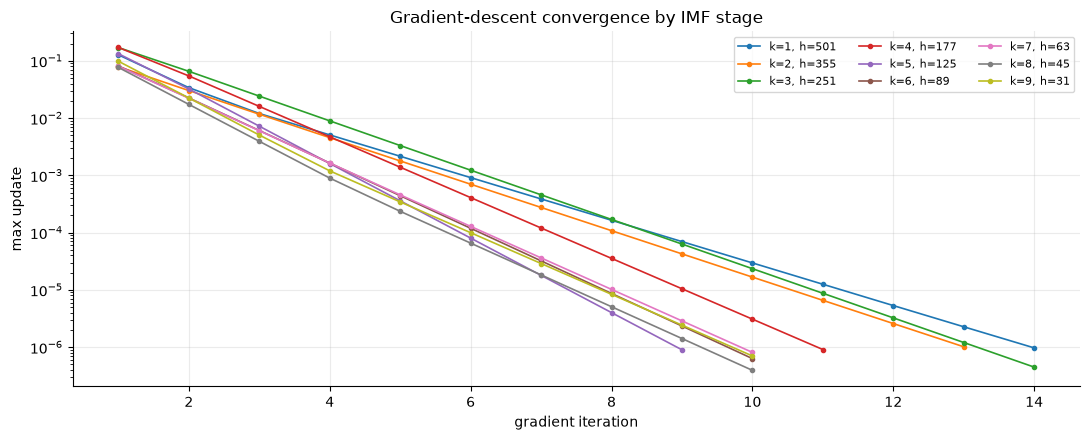

In [48]:
fig, ax = plt.subplots(figsize=(11, 4.5))

for info in result["stage_info"]:
    trace = info["trace"]
    ax.plot(
        np.arange(1, len(trace) + 1),
        trace,
        marker="o",
        markersize=3,
        linewidth=1.2,
        label=f"k={info['stage']}, h={info['window_size']}",
    )

ax.set_yscale("log")
ax.set_title("Gradient-descent convergence by IMF stage")
ax.set_xlabel("gradient iteration")
ax.set_ylabel("max update")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()


## Parallel consistency check

This check runs a smaller decomposition once with one worker and once with multiple
workers. The values should agree up to the small tolerance induced by independent
chunk stopping.


In [49]:
small_n = 200
small_t = np.linspace(0.0, 1.0, small_n)
small_clean, _ = gen_signal(small_t)
small_y, _ = generate_observation(
    small_clean,
    sigma=sigma,
    contamination_prob=0.06,
    contamination_scale=1.5,
    rng=np.random.default_rng(1234),
)
small_window_sizes = make_window_schedule(small_n, factor=np.sqrt(2.0), min_window_size=31)

single_worker = robust_gd_imf_with_history(
    small_y,
    small_window_sizes,
    H=H,
    grid=lookup_grid,
    max_iter=60,
    tol=1e-6,
    max_workers=1,
)
multi_worker = robust_gd_imf_with_history(
    small_y,
    small_window_sizes,
    H=H,
    grid=lookup_grid,
    max_iter=60,
    tol=1e-6,
    max_workers=min(2, DEFAULT_MAX_WORKERS),
)

parallel_max_error = np.max(np.abs(single_worker["imfs"] - multi_worker["imfs"]))

assert np.allclose(single_worker["imfs"], multi_worker["imfs"], atol=5e-5)
assert np.allclose(single_worker["residual"], multi_worker["residual"], atol=5e-5)

pd.DataFrame([
    {"check": "small first window", "value": small_window_sizes[0]},
    {"check": "single/multi IMF max abs diff", "value": parallel_max_error},
    {"check": "single reconstruction max error", "value": np.max(np.abs(small_y - single_worker["reconstruction"]))},
    {"check": "multi reconstruction max error", "value": np.max(np.abs(small_y - multi_worker["reconstruction"]))},
])


,check,value
0,small first window,1.010000e+02
1,single/multi IMF max abs diff,4.389183e-07
2,single reconstruction max error,4.440892e-16
3,multi reconstruction max error,8.881784e-16


## Notes and extensions

The common mistake is to parallelize the IMF stages themselves. That changes the
algorithm, because stage $k+1$ needs the residual from stage $k$. The independent
work is inside a stage: one scalar contrast problem per local window.

For a quick experiment, change `H`, `zmax`, or `num` in the lookup grid and rerun the
validation cell before rerunning the decomposition.
